<a href="https://www.kaggle.com/code/michelepulvirenti/house-plant-disease-recognition" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import random
from tqdm import tqdm
import numpy as np
from PIL import Image
import math

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.utils import class_weight

import matplotlib.pyplot as plt

2026-01-29 17:26:40.745865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769707600.950965      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769707601.009905      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769707601.488397      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769707601.488445      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769707601.488448      24 computation_placer.cc:177] computation placer alr

# Parameters

In [2]:
batch_size = 32
image_size = 256
dataset_dir = '/kaggle/input/indoor-plant-disease-dataset-23-classes/dataset_flat_structure'

train_dir= os.path.join(dataset_dir, "train")
val_dir= os.path.join(dataset_dir, "validation")
test_dir= os.path.join(dataset_dir, "test")

# Dataset loading

In [3]:
# --- Image preprocessing ---
def preprocess_pil_image(pil_img):
    # Handle images with palette or transparency
    if pil_img.mode in ("P", "RGBA"):
        pil_img = pil_img.convert("RGBA")  # Preserve transparency if needed
        # Convert RGBA → RGB by compositing on white background
        background = Image.new("RGBA", pil_img.size, (255, 255, 255, 255))
        pil_img = Image.alpha_composite(background, pil_img).convert("RGB")
    elif pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")

    img_resized = pil_img.resize((image_size, image_size))
    img_array = np.array(img_resized)
    return img_array

def load_and_preprocess_dataset(data_dir, class_to_id=None):
    """
    Loads images from a directory structure, preprocesses them, and returns numpy arrays.
    
    Args:
        data_dir (str): Path to the directory (e.g., train_dir or valid_dir).
        class_to_id (dict, optional): Existing mapping of class names to integers. 
                                      If None, it will be generated from the directory.
    
    Returns:
        images (np.array), labels (np.array), class_to_id (dict)
    """
    # Get class names from folder names
    class_names = sorted(os.listdir(data_dir))
    
    # If no mapping is provided (usually for training), create one
    if class_to_id is None:
        class_to_id = {name: i for i, name in enumerate(class_names)}
        print(f"🌿 Created new class mapping: {class_to_id}")
    else:
        print(f"🔄 Using provided class mapping.")

    images, labels = [], []

    for class_name in tqdm(class_names, desc=f"Processing {os.path.basename(data_dir)}"):
        class_path = os.path.join(data_dir, class_name)
        
        # Ensure it's a directory and that the class exists in our mapping
        if not os.path.isdir(class_path) or class_name not in class_to_id:
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                # Load and preprocess (assumes preprocess_pil_image is defined globally)
                pil_image = Image.open(img_path).convert('RGB') # Convert to RGB for consistency
                img_pp = preprocess_pil_image(pil_image)
                
                images.append(img_pp)
                labels.append(class_to_id[class_name])
            except Exception as e:
                # Silencing typical non-image file errors, but reporting critical failures
                pass

    images = np.array(images)
    labels = np.array(labels)

    print(f"✅ Finished {os.path.basename(data_dir)}. Shape: {images.shape}")
    return images, labels, class_to_id

In [4]:
X_train, y_train, master_mapping = load_and_preprocess_dataset(train_dir)

X_val, y_val, _ = load_and_preprocess_dataset(val_dir, class_to_id=master_mapping)

class_names = id_to_class = {v: k for k, v in master_mapping.items()}

🌿 Created new class mapping: {'Chrysanthemum_Bacterial_Leaf_Spot': 0, 'Chrysanthemum_Healthy': 1, 'Chrysanthemum_Septoria_Leaf_Spot': 2, 'Hibiscus_Blight': 3, 'Hibiscus_Healthy': 4, 'Hibiscus_Necrosis': 5, 'Hibiscus_Scorch': 6, 'Money Plant_Money_Plant_Bacterial_Wilt': 7, 'Money Plant_Money_Plant_Chlorosis': 8, 'Money Plant_Money_Plant_Healthy': 9, 'Money Plant_Money_Plant_Manganese_Toxicity': 10, 'Rose_Black_Spot': 11, 'Rose_Downy_Mildew': 12, 'Rose_Healthy': 13, 'Rose_Mosaic_Virus': 14, 'Rose_Powdery_Mildew': 15, 'Rose_Rust': 16, 'Rose_Yellow_Mosaic_Virus': 17, 'Turmeric_Aphid_Infestation': 18, 'Turmeric_Blotch': 19, 'Turmeric_Healthy': 20, 'Turmeric_Leaf_Necrosis': 21, 'Turmeric_Leaf_Spot': 22}


Processing train: 100%|██████████| 23/23 [03:32<00:00,  9.24s/it]


✅ Finished train. Shape: (21523, 256, 256, 3)
🔄 Using provided class mapping.


Processing validation: 100%|██████████| 23/23 [00:57<00:00,  2.51s/it]


✅ Finished validation. Shape: (6149, 256, 256, 3)


# Dataset info

In [5]:
unique_labels, counts = np.unique(y_train, return_counts=True)
print("Labels distribution:", dict(zip(unique_labels, counts)))

num_classes = len(set(y_train))
print("Number of classes:", num_classes)

Labels distribution: {np.int64(0): np.int64(537), np.int64(1): np.int64(537), np.int64(2): np.int64(537), np.int64(3): np.int64(840), np.int64(4): np.int64(840), np.int64(5): np.int64(840), np.int64(6): np.int64(840), np.int64(7): np.int64(403), np.int64(8): np.int64(81), np.int64(9): np.int64(1932), np.int64(10): np.int64(417), np.int64(11): np.int64(2100), np.int64(12): np.int64(771), np.int64(13): np.int64(3871), np.int64(14): np.int64(700), np.int64(15): np.int64(700), np.int64(16): np.int64(700), np.int64(17): np.int64(476), np.int64(18): np.int64(593), np.int64(19): np.int64(1333), np.int64(20): np.int64(1264), np.int64(21): np.int64(568), np.int64(22): np.int64(643)}
Number of classes: 23


Displaying one sample per label:


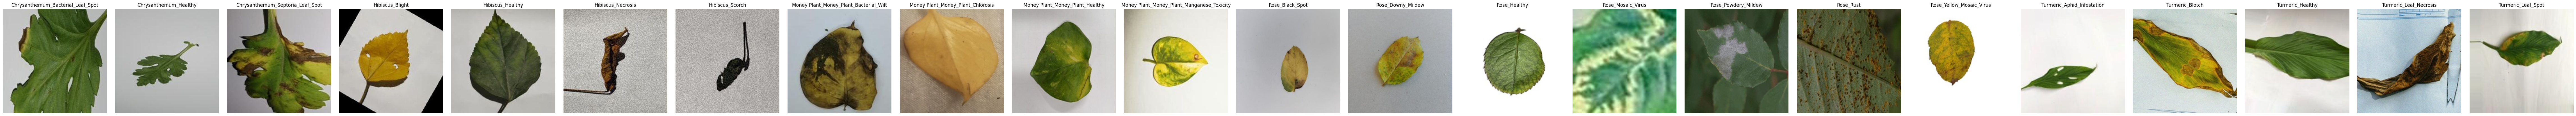

In [6]:
print("Displaying one sample per label:")
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

if len(unique_labels) == 1:
    axes = [axes]  # Handle single-class edge case

for i, label_id in enumerate(unique_labels):
    # Find the first sample index for this label
    idx = np.where(y_train == label_id)[0][0]
    img = X_train[idx]

    axes[i].imshow(img)
    axes[i].set_title(class_names[label_id])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Training

## Model

In [7]:
# Step 4: Build the model (Transfer Learning)

base_model = EfficientNetV2B0(
    input_shape=(image_size, image_size, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False  # Freeze base model

inputs = layers.Input(shape=(image_size, image_size, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=loss,
              metrics=['accuracy'])

model.summary()

I0000 00:00:1769707892.229168      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,948,775 (22.69 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Data augmentation

In [8]:
y_train = to_categorical(y_train, num_classes=len(master_mapping))
y_val = to_categorical(y_val, num_classes=len(master_mapping))

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),

    layers.RandomZoom(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.08),
    layers.RandomSaturation(0.1),
    layers.RandomHue(0.02),

    layers.RandomErasing(
        factor=(0, 0.1),   # Area of erased region (10–20%)
        scale=(0.02, 0.33),    # Aspect ratio range
        fill_value=0.0     # Black fill
    ),

    layers.GaussianNoise(0.005),
])


# Using augmentation in a dataset pipeline
def augment_and_preprocess(img, label):
    # 1. Cast and Augment (Expects 0-255 range usually)
    img = tf.cast(img, tf.float32)
    img = data_augmentation(img, training=True) 
    
    # 2. Clip to ensure we stay in valid pixel range [0, 255]
    img = tf.clip_by_value(img, 0.0, 255.0)
    
    # 3. Apply model-specific preprocessing (e.g., ResNet/MobileNet)
    img = preprocess_input(img)
    
    return img, label
    
# If you prepare a tf.data.Dataset (recommended for large datasets):
# Assuming X_train, y_train are NumPy arrays of images and labels
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024)

train_dataset = train_dataset.map(
    augment_and_preprocess, # Pass the function directly
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# For validation, do NOT apply augmentation:
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

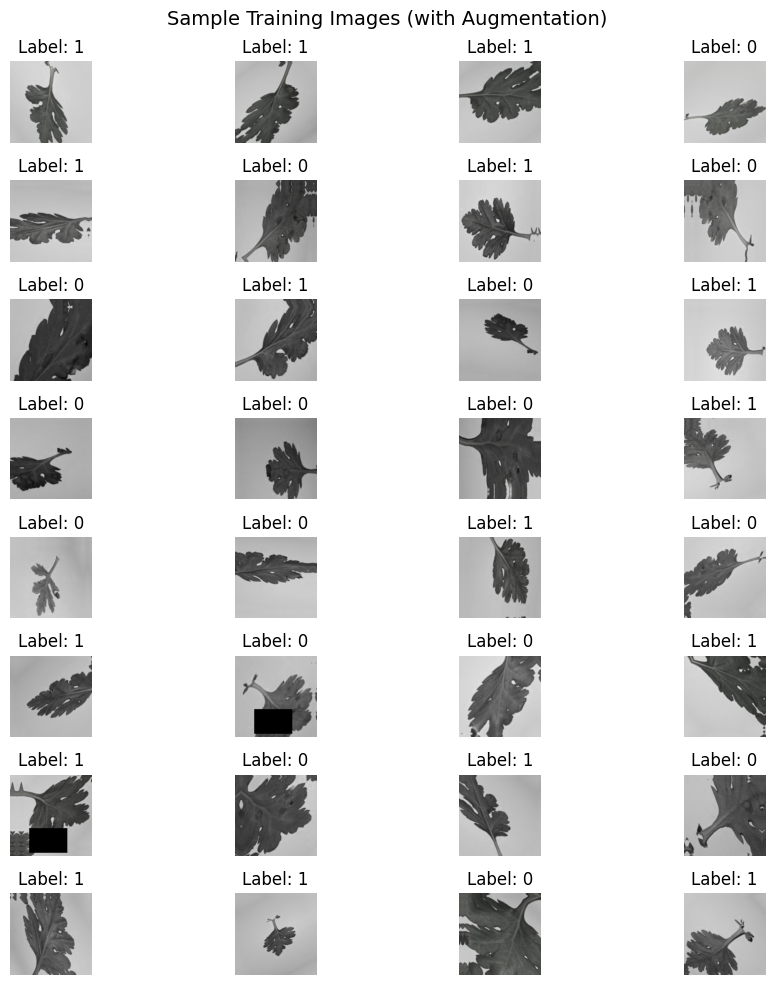

In [10]:
sample_images, sample_labels = next(iter(train_dataset.unbatch().batch(batch_size)))

plt.figure(figsize=(10, 10))

num_samples = len(sample_images)
cols = 4
rows = math.ceil(num_samples / cols)

for i in range(num_samples):
    plt.subplot(rows, cols, i + 1)
    img = np.clip(sample_images[i].numpy() / 255.0, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {np.argmax(sample_labels[i])}")
    plt.axis("off")

plt.suptitle("Sample Training Images (with Augmentation)", fontsize=14)
plt.tight_layout()
plt.show()


## Training model

In [11]:
y_integers = np.argmax(y_train, axis=1)

weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(y_integers), 
                                            y=y_integers)
class_weights = dict(enumerate(weights))
class_weights

{0: np.float64(1.7426119342563355),
 1: np.float64(1.7426119342563355),
 2: np.float64(1.7426119342563355),
 3: np.float64(1.1140269151138715),
 4: np.float64(1.1140269151138715),
 5: np.float64(1.1140269151138715),
 6: np.float64(1.1140269151138715),
 7: np.float64(2.322041212644298),
 8: np.float64(11.552871712292003),
 9: np.float64(0.484359528310379),
 10: np.float64(2.244082994473986),
 11: np.float64(0.44561076604554867),
 12: np.float64(1.2137258219139457),
 13: np.float64(0.24174182606449293),
 14: np.float64(1.336832298136646),
 15: np.float64(1.336832298136646),
 16: np.float64(1.336832298136646),
 17: np.float64(1.96592985020095),
 18: np.float64(1.5780482440061587),
 19: np.float64(0.7020124596366483),
 20: np.float64(0.7403343423225096),
 21: np.float64(1.6475045927740355),
 22: np.float64(1.4553384272094123)}

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# When training, use train_dataset and val_dataset instead of NumPy arrays
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/50


I0000 00:00:1769707931.190418      68 service.cc:152] XLA service 0x7b39640047e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769707931.190467      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769707936.074389      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769707950.817383      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


673/673 ━━━━━━━━━━━━━━━━━━━━ 411s 557ms/step - accuracy: 0.6803 - loss: 1.8147 - val_accuracy: 0.4531 - val_loss: 1.9165
Epoch 2/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 348s 516ms/step - accuracy: 0.8413 - loss: 1.2994 - val_accuracy: 0.6930 - val_loss: 1.4870
Epoch 3/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 349s 518ms/step - accuracy: 0.8946 - loss: 1.1425 - val_accuracy: 0.7374 - val_loss: 1.3953
Epoch 4/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 351s 521ms/step - accuracy: 0.9141 - loss: 1.0928 - val_accuracy: 0.7746 - val_loss: 1.3422
Epoch 5/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 348s 517ms/step - accuracy: 0.9266 - loss: 1.0648 - val_accuracy: 0.8213 - val_loss: 1.2547
Epoch 6/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 349s 519ms/step - accuracy: 0.9260 - loss: 1.0579 - val_accuracy: 0.8222 - val_loss: 1.2613
Epoch 7/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 350s 520ms/step - accuracy: 0.9301 - loss: 1.0441 - val_accuracy: 0.8211 - val_loss: 1.2497
Epoch 8/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 351s 521ms/step - accuracy: 0.9376 - loss: 1.03

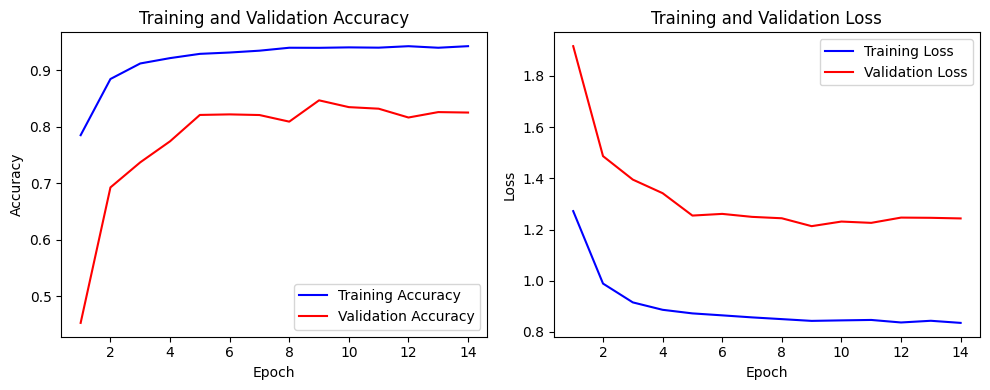

In [13]:
# Extract metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
print(f"Training Accuracy: {acc[-1]:.4f}")
print(f"Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Training Loss: {loss[-1]:.4f}")
print(f"Validation Loss: {val_loss[-1]:.4f}")

Training Accuracy: 0.9430
Validation Accuracy: 0.8255
Training Loss: 0.8355
Validation Loss: 1.2436


In [15]:
# Step 6: Fine-tune the base model by unfreezing some layers
base_model.trainable = True
# Unfreeze only the top layers of base model for fine-tuning
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(train_dataset,
                         validation_data=val_dataset,
                         epochs=50,
                         callbacks=[early_stop],
                        class_weight=class_weights
)

Epoch 1/50


2026-01-29 18:55:38.733305: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 18:55:38.923131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 18:55:39.362740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 18:55:39.568985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


672/673 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.3884 - loss: 2.4474

2026-01-29 19:02:00.996864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 19:02:01.182032: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 19:02:01.601040: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 19:02:01.809619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


673/673 ━━━━━━━━━━━━━━━━━━━━ 470s 599ms/step - accuracy: 0.3884 - loss: 2.4462 - val_accuracy: 0.8208 - val_loss: 1.0515
Epoch 2/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 366s 543ms/step - accuracy: 0.5060 - loss: 1.9761 - val_accuracy: 0.8514 - val_loss: 0.7549
Epoch 3/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 364s 541ms/step - accuracy: 0.5693 - loss: 1.6570 - val_accuracy: 0.8569 - val_loss: 0.6394
Epoch 4/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 362s 537ms/step - accuracy: 0.6164 - loss: 1.4339 - val_accuracy: 0.8678 - val_loss: 0.5564
Epoch 5/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 364s 540ms/step - accuracy: 0.6725 - loss: 1.1940 - val_accuracy: 0.8536 - val_loss: 0.5579
Epoch 6/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 364s 540ms/step - accuracy: 0.7030 - loss: 1.1073 - val_accuracy: 0.8676 - val_loss: 0.5070
Epoch 7/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 369s 548ms/step - accuracy: 0.7418 - loss: 0.9348 - val_accuracy: 0.8681 - val_loss: 0.4864
Epoch 8/50
673/673 ━━━━━━━━━━━━━━━━━━━━ 369s 548ms/step - accuracy: 0.7659 - loss: 0.87

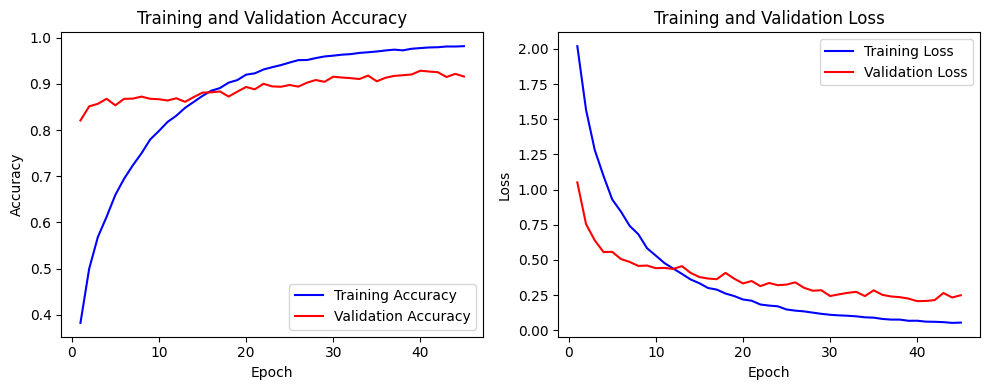

In [16]:
# Extract metrics
acc_fine = history_fine.history['accuracy']
val_acc_fine = history_fine.history['val_accuracy']
loss_fine = history_fine.history['loss']
val_loss_fine = history_fine.history['val_loss']

epochs = range(1, len(acc_fine) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc_fine, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc_fine, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_fine, 'b-', label='Training Loss')
plt.plot(epochs, val_loss_fine, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
print(f"Final Training Accuracy: {acc_fine[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc_fine[-1]:.4f}")
print(f"Final Training Loss: {loss_fine[-1]:.4f}")
print(f"Final Validation Loss: {val_loss_fine[-1]:.4f}")

Final Training Accuracy: 0.9818
Final Validation Accuracy: 0.9161
Final Training Loss: 0.0553
Final Validation Loss: 0.2495


# Saving model

In [18]:
# Step 7: Export model to a TensorFlow SavedModel directory
MODEL_DIR = '/kaggle/working/houseplant_classifier_model'  # no .keras extension
model.export(MODEL_DIR)  # creates a folder with saved_model.pb etc.

# Step 8: Convert to TensorFlow Lite model
# converter = tf.lite.TFLiteConverter.from_saved_model(MODEL_DIR)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
# tflite_model = converter.convert()

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Compatibility flags
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

# (Optional) For older devices
# converter._experimental_lower_tensor_list_ops = False

# Convert
tflite_model = converter.convert()

with open('/kaggle/working/houseplant_classifier_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ TensorFlow Lite model saved as houseplant_classifier_model.tflite")

INFO:tensorflow:Assets written to: /kaggle/working/houseplant_classifier_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/houseplant_classifier_model/assets


Saved artifact at '/kaggle/working/houseplant_classifier_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_271')
Output Type:
  TensorSpec(shape=(None, 23), dtype=tf.float32, name=None)
Captures:
  135494990460880: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135494990460688: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135494990461456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990462032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990461840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990459728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990461648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990461072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494972867408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494972867024: TensorSpec(shape=

INFO:tensorflow:Assets written to: /tmp/tmpqm7tr7d6/assets


Saved artifact at '/tmp/tmpqm7tr7d6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_271')
Output Type:
  TensorSpec(shape=(None, 23), dtype=tf.float32, name=None)
Captures:
  135494990460880: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135494990460688: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135494990461456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990462032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990461840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990459728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990461648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494990461072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494972867408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135494972867024: TensorSpec(shape=(), dtype=tf.resource, name

W0000 00:00:1769729533.311483      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1769729533.311541      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1769729533.569526      24 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


✅ TensorFlow Lite model saved as houseplant_classifier_model.tflite
